In [1]:
!pip install ultralytics opencv-python matplotlib pillow --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 22.8 MB/s eta 0:00:00


In [2]:
from google.colab import drive
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
import os
drive.mount('/content/drive')

# === CHANGE THESE PATHS TO MATCH YOUR DRIVE ===
PROJECT_ROOT = "/content/drive/MyDrive/AER850 Project3/Project 3 Data"

# Part 1 (masking)
motherboard_pic = f"{PROJECT_ROOT}/motherboard_image.JPEG"

# YOLO dataset folder (the 'data' folder)
yolo_data = f"{PROJECT_ROOT}/data"

# YAML file inside the data folder
yaml_data = f"{yolo_data}/data.yaml"

print("Project root:", PROJECT_ROOT)
print("Dataset root:", yolo_data)
print("Motherboard image:", motherboard_pic)
print("Dataset yaml:", yaml_data)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Mounted at /content/drive
Project root: /content/drive/MyDrive/AER850 Project3/Project 3 Data
Dataset root: /content/drive/MyDrive/AER850 Project3/Project 3 Data/data
Motherboard image: /content/drive/MyDrive/AER850 Project3/Project 3 Data/motherboard_image.JPEG
Dataset yaml: /content/drive/MyDrive/AER850 Project3/Project 3 Data/data/data.yaml


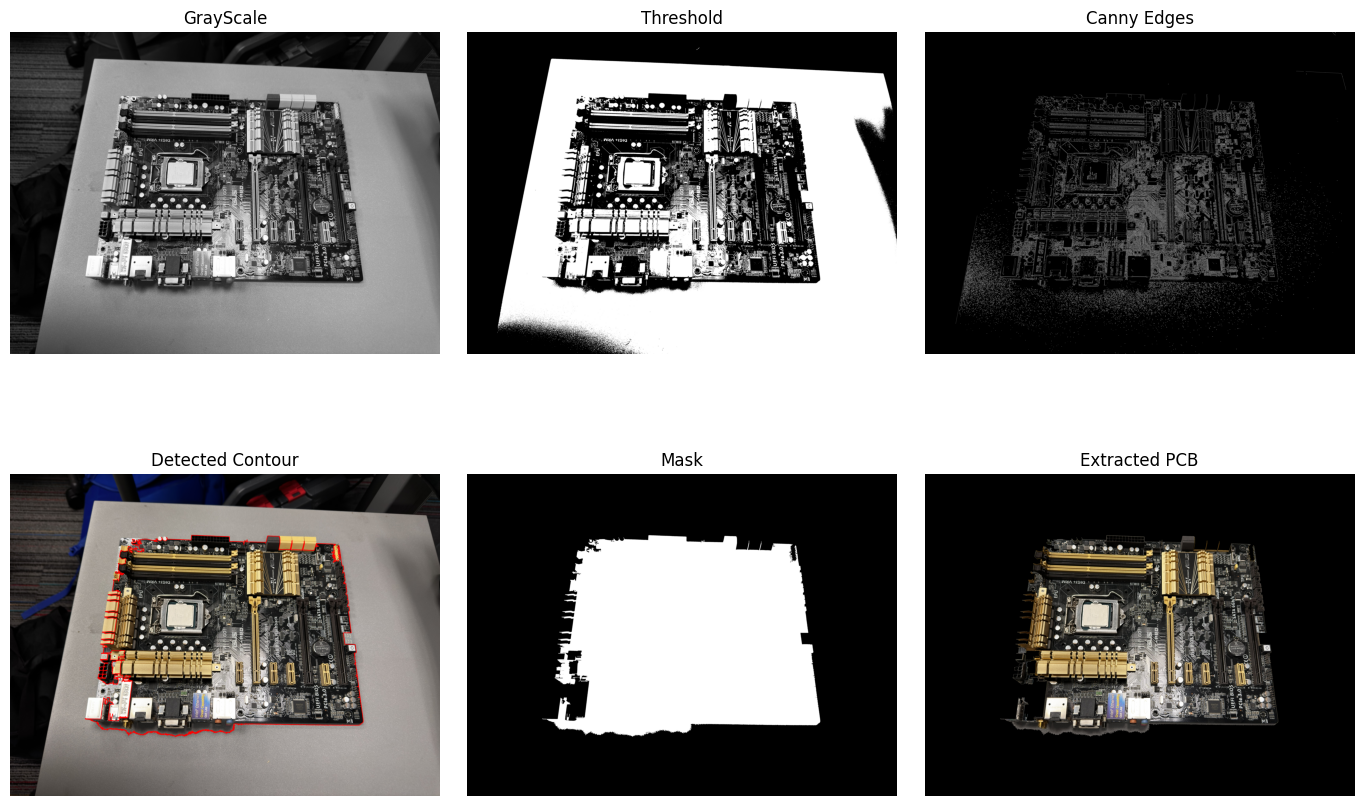

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
import os
original = cv2.imread(motherboard_pic)
image = cv2.rotate(original, cv2.ROTATE_90_CLOCKWISE)
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Thresholding
_, threshold = cv2.threshold(gray_image, 100, 255, cv2.THRESH_BINARY)


# Apply Gaussian blur to reduce noise
blur = cv2.GaussianBlur(threshold, (5, 5), 0)

# Apply Canny edge detection
edges = cv2.Canny(gray_image, 100, 200)

# Contour detection
contours, _ = cv2.findContours(threshold, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)

max_contour = None
max_area = 0
#Contour-Filtering Loop
for cnt in contours:
    area = cv2.contourArea(cnt)
    x, y, w, h = cv2.boundingRect(cnt)
    ar = w / float(h)
    # skip invalid contours immediately
    if w <= 150 or h <= 150:
        continue
    if not (0.6 < ar < 1.7):
        continue
    if area >= 16000000:
        continue
    # update best contour
    if area > max_area:
        max_area = area
        max_contour = cnt

# Filter and draw the largest contour
contour_image = image.copy()
cv2.drawContours(contour_image, [max_contour], -1, (0, 0, 255), 7)

# Mask the motherboard using the largest contour
mask = np.zeros_like(gray_image)
cv2.drawContours(mask, [max_contour], -1, 255, thickness=cv2.FILLED)
extracted = cv2.bitwise_and(image, image, mask=mask)

# Display results using matplotlib
plt.figure(figsize=(14, 10))

# --- GrayScale Image ---
plt.subplot(2, 3, 1)
plt.imshow(gray_image, cmap='gray')
plt.title('GrayScale')
plt.axis('off')

# --- Threshold Image ---
plt.subplot(2, 3, 2)
plt.imshow(threshold, cmap='gray')
plt.title('Threshold')
plt.axis('off')

# --- Canny Edges ---
plt.subplot(2, 3, 3)
plt.imshow(edges, cmap='gray')
plt.title('Canny Edges')
plt.axis('off')

# --- Contour Overlay ---
plt.subplot(2, 3, 4)
plt.imshow(cv2.cvtColor(contour_image, cv2.COLOR_BGR2RGB))
plt.title('Detected Contour')
plt.axis('off')

# --- Mask Image ---
plt.subplot(2, 3, 5)
plt.imshow(mask, cmap='gray')
plt.title('Mask')
plt.axis('off')

# --- Extracted PCB ---
plt.subplot(2, 3, 6)
plt.imshow(cv2.cvtColor(extracted, cv2.COLOR_BGR2RGB))
plt.title('Extracted PCB')
plt.axis('off')

# Display the plots
plt.tight_layout(pad=2.0)
plt.show()

In [4]:
#Step 2 YOLOv11 Training
# Load the YOLOv11 nano model
model = YOLO('yolo11n.pt')  # 'n' refers to the nano version

# Train the model
model.train(
    data=yaml_data,  # Path to the data.yaml file
    epochs=150,                # Number of training epochs
    imgsz=1200,                 # Image size for training (default 640)
    batch=5,                  # Batch size (adjust based on your GPU memory)
    name = 'PCB_Component_Detection_Model'
)
# =====================================================================
# ====================   ALL VISUALIZATION BELOW   ====================
# =====================================================================

Ultralytics 8.3.228 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=5, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/AER850 Project3/Project 3 Data/data/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1200, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=PCB_Component_Detection_Model, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, ove

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79935c198590>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.04504

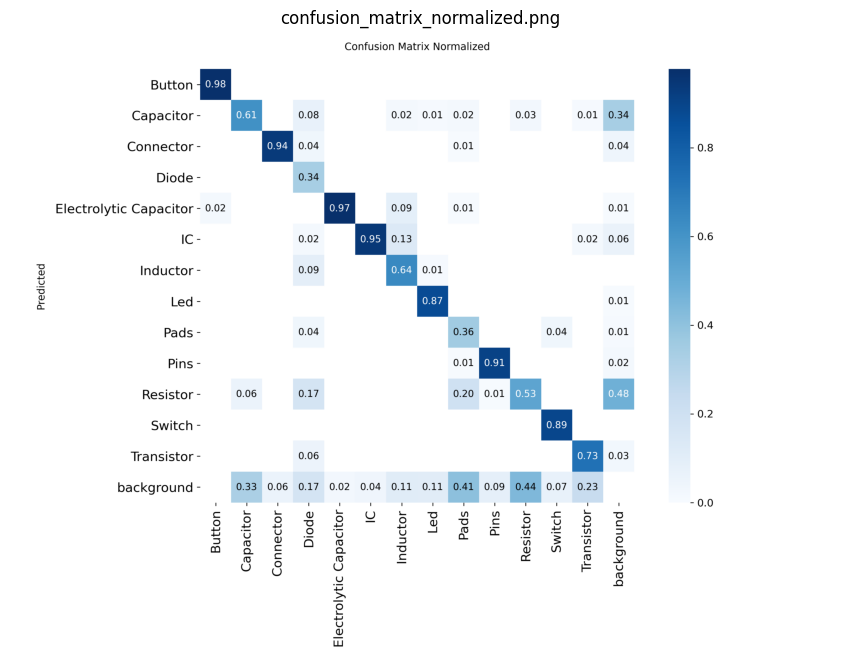

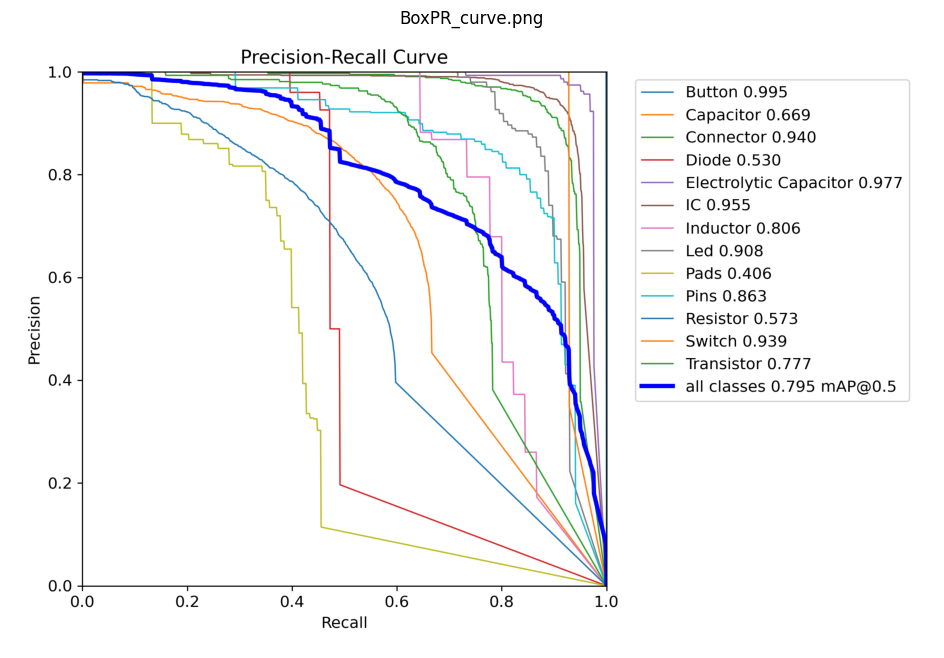

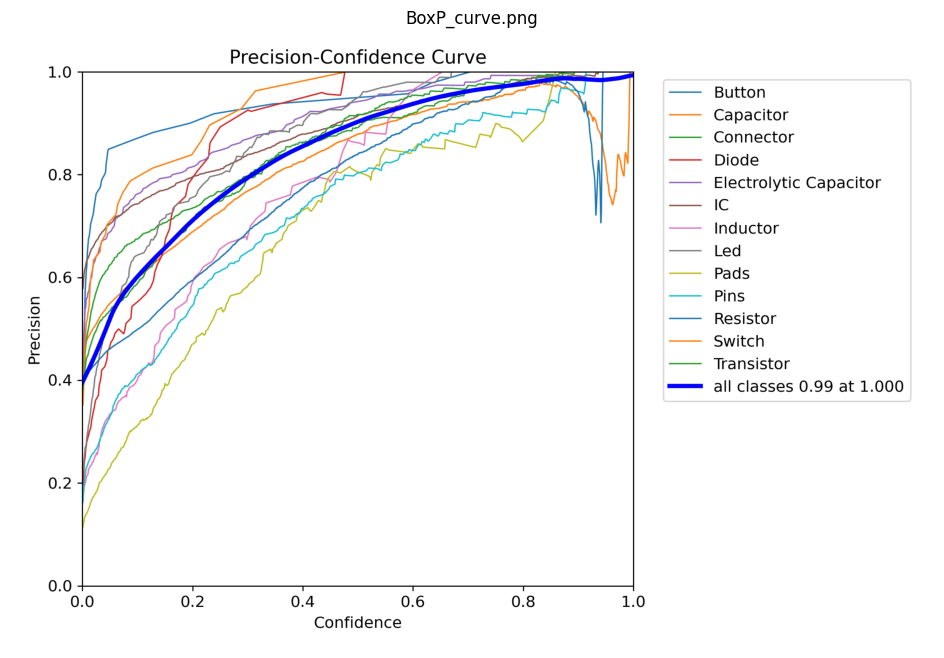


image 1/1 /content/drive/MyDrive/AER850 Project3/Project 3 Data/data/evaluation/ardmega.jpg: 1088x1216 10 Capacitors, 8 Connectors, 1 Diode, 6 ICs, 18 Resistors, 19.8ms
Speed: 16.9ms preprocess, 19.8ms inference, 2.0ms postprocess per image at shape (1, 3, 1088, 1216)


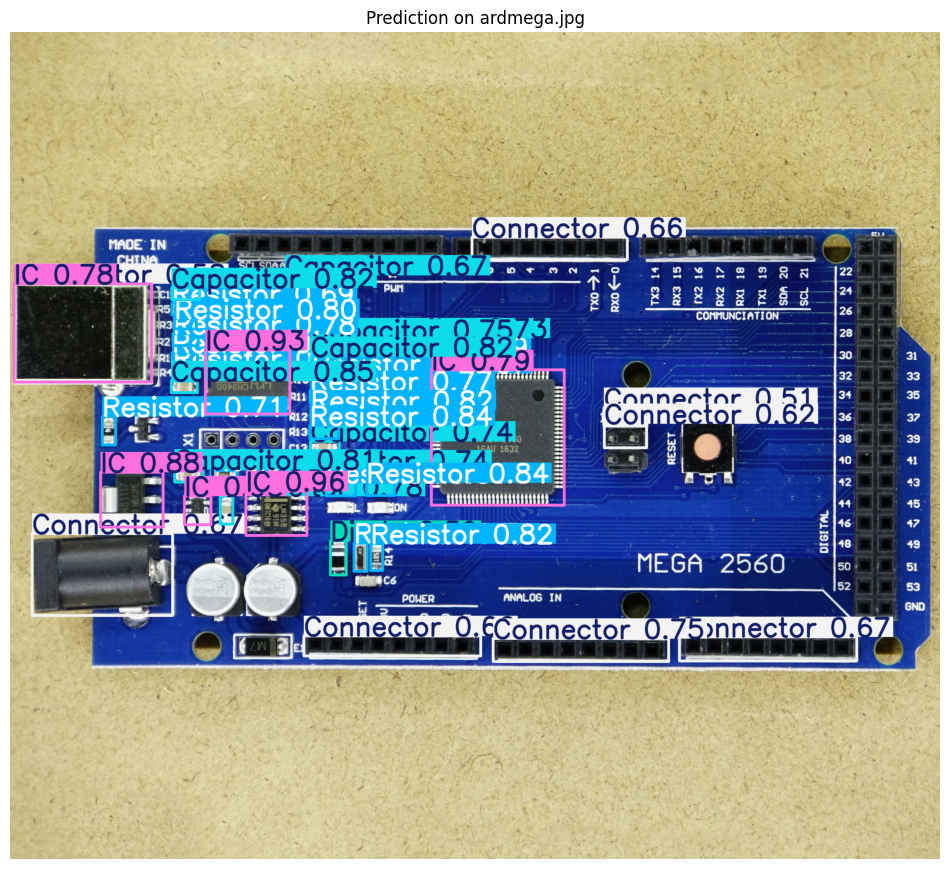


image 1/1 /content/drive/MyDrive/AER850 Project3/Project 3 Data/data/evaluation/arduno.jpg: 832x1216 9 Capacitors, 6 Connectors, 1 Diode, 2 Electrolytic Capacitors, 4 ICs, 1 Led, 6 Resistors, 20.3ms
Speed: 14.5ms preprocess, 20.3ms inference, 3.8ms postprocess per image at shape (1, 3, 832, 1216)


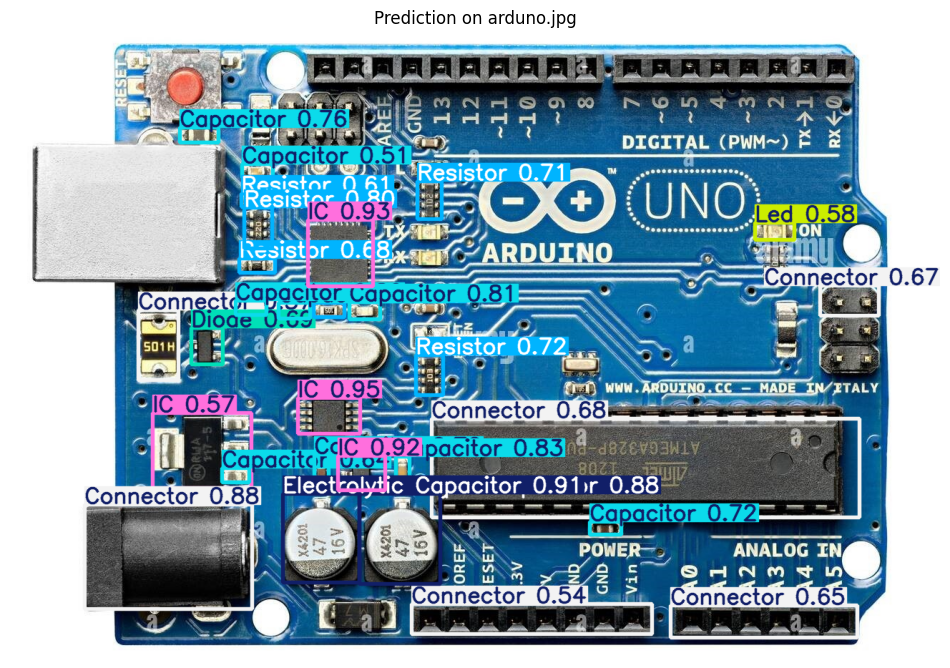


image 1/1 /content/drive/MyDrive/AER850 Project3/Project 3 Data/data/evaluation/rasppi.jpg: 832x1216 5 Capacitors, 9 Connectors, 1 Electrolytic Capacitor, 9 ICs, 2 Padss, 3 Resistors, 14.1ms
Speed: 11.2ms preprocess, 14.1ms inference, 1.9ms postprocess per image at shape (1, 3, 832, 1216)


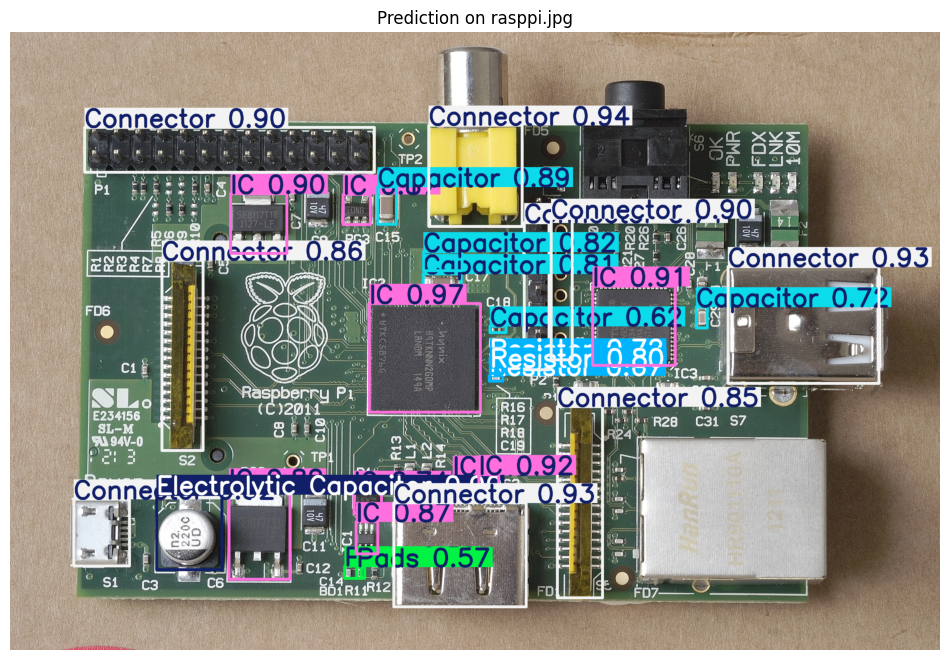

In [12]:
# Show common YOLO training plots if they exist in the run folder
# Folder where YOLO saved all training results
RUN_ROOT = "runs/detect"
RUN_NAME = "PCB_Component_Detection_Model"   # MUST match Step 2
RUN_DIR  = f"{RUN_ROOT}/{RUN_NAME}"

plot_files = [
    "confusion_matrix_normalized.png",  # confusion matrix
    "BoxPR_curve.png",          # precision-recall curve
    "BoxP_curve.png"            # precision vs confidence
]

for fname in plot_files:
    fpath = os.path.join(RUN_DIR, fname)
    if os.path.exists(fpath):
        img = plt.imread(fpath)
        plt.figure(figsize=(12, 8))
        plt.imshow(img)
        plt.title(fname)
        plt.axis("off")
        plt.show()
    else:
        print(f"[INFO] {fname} not found in {RUN_DIR}")

#Step 3 Evaluation of Model
# Paths to test images for evaluation
test_image_paths = [
    f'{PROJECT_ROOT}/data/evaluation/ardmega.jpg',
    f'{PROJECT_ROOT}/data/evaluation/arduno.jpg',
    f'{PROJECT_ROOT}/data/evaluation/rasppi.jpg'
]


# Evaluate each test image
for image_path in test_image_paths:
    results = model.predict(source=image_path, conf=0.5)  # Confidence threshold at 0.5

    # Display prediction results
    for result in results:
        plt.figure(figsize=(12, 12))
        rgb_img = cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB)
        plt.imshow(rgb_img)
        plt.title(f"Prediction on {image_path.split('/')[-1]}")
        plt.axis("off")
        plt.show()